# Artifact Rejection & Preprocessing

Before any analysis, raw iEEG data needs to be cleaned. This notebook covers:

1. What artifacts are and why they matter
2. Identifying bad channels
3. Detecting and removing noisy time segments
4. A minimal preprocessing pipeline

**What we assume:** You have already worked through Notebook 1 and have the data downloaded to your Google Drive.

## What is an artifact?

An **artifact** is any signal that does not come from neural activity. In iEEG recordings, the most common sources are:

| Artifact type | Origin | Appearance |
|---|---|---|
| Line noise | Power grid (50/60 Hz) | Sharp peak in PSD at 50, 100, 150 Hz |
| Movement | Patient or cable shift | Sudden large amplitude jump |
| Bad contact | Electrode not seated properly | Channel is flat or extremely noisy throughout |
| Cardiac (pulse) | Heartbeat near electrode | Rhythmic ~1 Hz spike |
| Reference noise | Common reference electrode picks up noise | Noise appears in all channels simultaneously |

Unlike scalp EEG, iEEG does **not** have muscle or eye movement artifacts — the skull and dura are between the patient and those sources. But iEEG is far more sensitive to local electrical interference.

The goal of preprocessing is to remove these artifacts so that only neural signal remains.

In [ ]:
# install packages
!pip install mne mne-bids

# mount google drive with the data
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data (same file as Notebook 1)
homepath = '/content/drive/MyDrive/iEEG_course_UCL'
vhdr_path = Path(homepath) / 'ds003498/sub-02/ses-interictalsleep/ieeg/sub-02_ses-interictalsleep_run-01_ieeg.vhdr'

raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
print(f"Loaded: {len(raw.ch_names)} channels, {raw.times[-1]:.0f} seconds")

Loaded: 64 channels, 300 seconds


## Identify bad channels

A **bad channel** is one that records mostly noise rather than neural signal throughout the recording. We identify them by looking at two properties:

- **Variance**: A flatline channel has near-zero variance. An extremely noisy channel has abnormally high variance.
- **Correlation with neighbours**: A genuine neural signal is correlated with nearby electrodes (because they share some of the same neural population). A bad channel has low correlation with everything.

We compute variance for every channel and flag the outliers.

In [ ]:
# Compute variance for every channel
data = raw.get_data()  # shape: (n_channels, n_timepoints)
channel_variance = np.var(data, axis=1)

# Channels more than 3 standard deviations from the mean are suspicious
mean_var = np.mean(channel_variance)
std_var  = np.std(channel_variance)

suspicious = [raw.ch_names[i] for i, v in enumerate(channel_variance)
              if v > mean_var + 3 * std_var or v < mean_var - 3 * std_var]

print(f"Suspicious channels (outlier variance): {suspicious}")

Suspicious channels (outlier variance): ['AHR1']


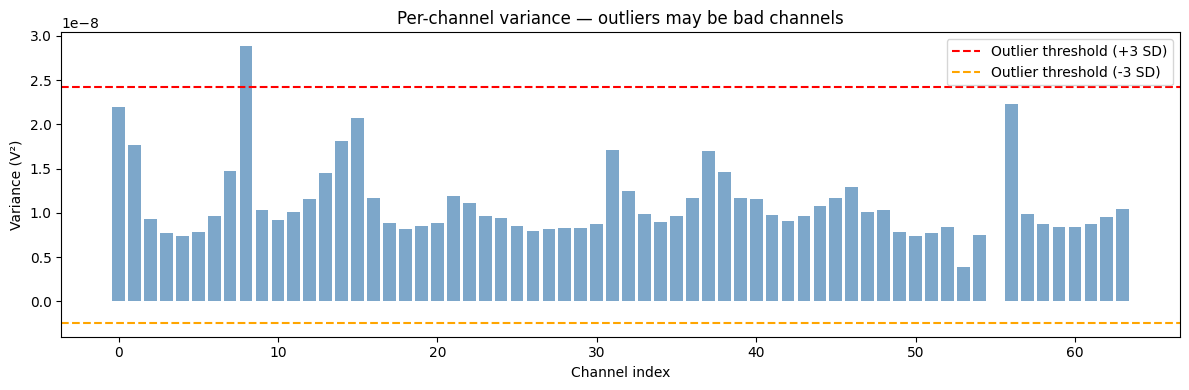


A channel far above the threshold is excessively noisy.
A channel far below (near zero) is flatlined.


In [ ]:
# Visualise — each dot is one channel
fig, ax = plt.subplots(figsize=(12, 4))

ax.bar(range(len(channel_variance)), channel_variance, color='steelblue', alpha=0.7)
ax.axhline(mean_var + 3 * std_var, color='red', ls='--', label='Outlier threshold (+3 SD)')
ax.axhline(mean_var - 3 * std_var, color='orange', ls='--', label='Outlier threshold (-3 SD)')

ax.set_xlabel('Channel index')
ax.set_ylabel('Variance (V²)')
ax.set_title('Per-channel variance — outliers may be bad channels')
ax.legend()
plt.tight_layout()
plt.show()

print("\nA channel far above the threshold is excessively noisy.")
print("A channel far below (near zero) is flatlined.")

Once bad channels are identified, we mark them in MNE so they are excluded from further analysis. We do **not** delete them — we just tell MNE to ignore them.

In [ ]:
# Mark suspicious channels as bad
raw.info['bads'] = suspicious
print(f"Marked as bad: {raw.info['bads']}")

# From now on, picks='data', exclude='bads' will automatically skip these

Marked as bad: ['AHR1']


## Identify noisy time segments

Even a good channel can have brief noisy moments — the patient moved, a cable was bumped, etc. We want to find and exclude these **time windows**.

The simplest approach: compute the signal amplitude in sliding windows. A window with abnormally high amplitude is likely an artifact.

In [ ]:
# Use only good channels
good_chs = [ch for ch in raw.ch_names if ch not in raw.info['bads']]
data_good = raw.get_data(picks=good_chs)  # (n_good_chs, n_timepoints)

fs = raw.info['sfreq']
window_sec = 1.0               # check every 1 second
step = int(window_sec * fs)

# For each 1-second window, compute peak-to-peak amplitude across all good channels
n_windows = data_good.shape[1] // step
window_times = []
window_amplitudes = []

for i in range(n_windows):
    seg = data_good[:, i*step : (i+1)*step]
    ptp = np.ptp(seg, axis=1).mean()  # mean peak-to-peak across channels
    window_times.append(i * window_sec)
    window_amplitudes.append(ptp * 1e6)  # convert to µV

window_amplitudes = np.array(window_amplitudes)

# Flag windows exceeding threshold
amplitude_threshold = np.percentile(window_amplitudes, 95)
noisy_windows = np.where(window_amplitudes > amplitude_threshold)[0]

print(f"Amplitude threshold (95th percentile): {amplitude_threshold:.0f} µV")
print(f"Noisy 1-second windows: {len(noisy_windows)} out of {n_windows}")

Amplitude threshold (95th percentile): 626 µV
Noisy 1-second windows: 15 out of 300


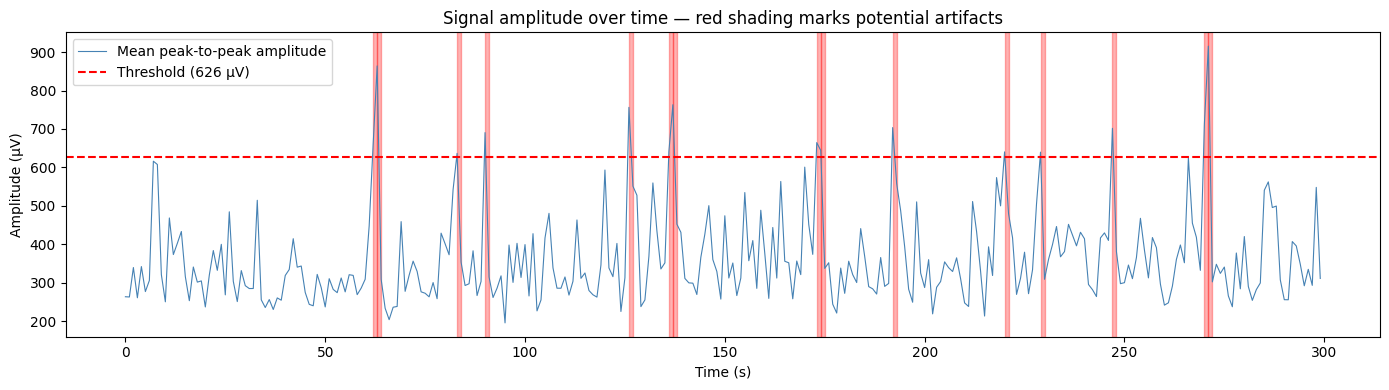

In [ ]:
# Plot amplitude over time — noisy windows highlighted in red
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(window_times, window_amplitudes, color='steelblue', lw=0.8, label='Mean peak-to-peak amplitude')
ax.axhline(amplitude_threshold, color='red', ls='--', label=f'Threshold ({amplitude_threshold:.0f} µV)')

for idx in noisy_windows:
    ax.axvspan(window_times[idx], window_times[idx] + window_sec, color='red', alpha=0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Signal amplitude over time — red shading marks potential artifacts')
ax.legend()
plt.tight_layout()
plt.show()

## A minimal preprocessing pipeline

Putting it all together, here is a clean preprocessing pipeline that goes from raw data to analysis-ready data in a few steps:

1. **Band-pass filter** (0.5–200 Hz) — remove DC drift and very high-frequency noise
2. **Notch filter** (50 Hz + harmonics) — remove line noise
3. **Mark bad channels** — exclude them from further analysis
4. **Re-reference** — change the reference from the original hardware reference to a common average reference

Step 4 deserves explanation:

### Re-referencing: what and why

Every voltage measurement is relative to a **reference electrode**. In iEEG, the hardware reference is often a single electrode outside the brain (e.g., on the skull). If that reference electrode picks up noise, every channel looks noisy.

The **common average reference (CAR)** uses the mean of all good channels as the reference. This spreads the reference noise across all channels equally, which often cancels it out. It also enhances local signal and suppresses global noise.

```
signal_rereferenced = signal_original - mean(all_good_channels)
```

This is the most widely used re-referencing method in iEEG research.

In [ ]:
# Full preprocessing pipeline

raw_clean = raw.copy()

# 1. Band-pass filter
raw_clean.filter(l_freq=0.5, h_freq=200.0, verbose=False)
print("1. Band-pass filter applied (0.5–200 Hz)")

# 2. Notch filter for line noise and harmonics
raw_clean.notch_filter(freqs=[50, 100, 150, 200], verbose=False)
print("2. Notch filter applied (50, 100, 150, 200 Hz)")

# 3. Bad channels already marked above
print(f"3. Bad channels marked: {raw_clean.info['bads']}")

# 4. Common average reference
raw_clean.set_eeg_reference('average', projection=False, verbose=False)
print("4. Common average reference applied")

print("\nPreprocessing complete.")

1. Band-pass filter applied (0.5–200 Hz)
2. Notch filter applied (50, 100, 150, 200 Hz)
3. Bad channels marked: ['AHR1']
4. Common average reference applied

Preprocessing complete.


Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_32788/2810068270.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  r.compute_psd(fmax=200).plot(picks='data', exclude='bads',


Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_32788/2810068270.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  r.compute_psd(fmax=200).plot(picks='data', exclude='bads',


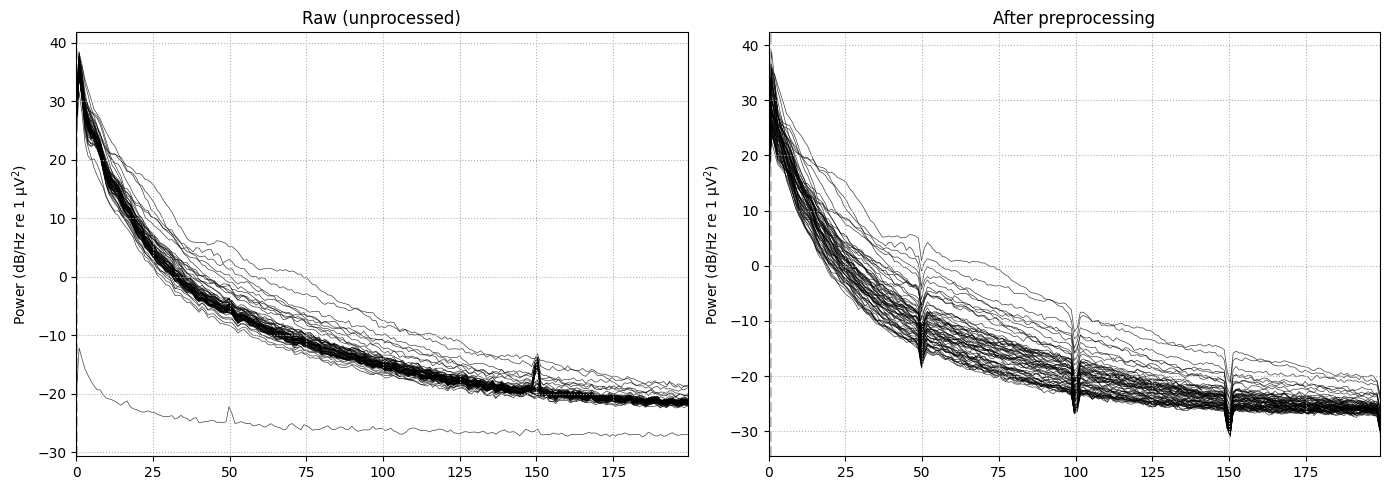

Notice: the 50 Hz peak and its harmonics should be gone in the right panel.


In [ ]:
# Compare raw vs preprocessed PSD side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r, title in zip(axes,
                        [raw, raw_clean],
                        ['Raw (unprocessed)', 'After preprocessing']):
    r.compute_psd(fmax=200).plot(picks='data', exclude='bads',
                                  amplitude=False, axes=ax, show=False)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

print("Notice: the 50 Hz peak and its harmonics should be gone in the right panel.")

## Summary

A clean preprocessing pipeline for iEEG consists of:

1. **Visual inspection** — always look at your data before doing anything
2. **Bad channel identification** — flag channels that are flatlined or excessively noisy
3. **Temporal artifact detection** — find noisy time windows and exclude them from analysis
4. **Filtering** — band-pass to keep the signal of interest, notch to kill line noise
5. **Re-referencing** — common average reference removes shared noise

The order matters: always filter before re-referencing so that filter edge effects do not propagate across channels.